In [1]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should return the number of GPUs
print(torch.cuda.get_device_name(0))  # Should show the GPU model

True
1
NVIDIA RTX 5000 Ada Generation


In [2]:
import transformers
import torch
import os
import json
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM
import logging
import time
from datetime import timedelta, datetime
import pandas as pd
from dotenv import load_dotenv
import shutil 

import evaluate
from sentence_transformers import SentenceTransformer, util
import numpy as np

# Load environment variables
load_dotenv(dotenv_path="../../.env") # path is relative to this script, adjust as needed

run_id = "LMForge_RUN01_Devices_Comparison_Lab_Machine_Qwen2.5-1.5B-Instruct"  # <- Change this manually for each experiment
batch_size = 10  # <- Change this manually for each experiment

In [3]:
from transformers.utils import LossKwargs


In [4]:
import logging
logging.basicConfig(filename='generation.log', level=logging.INFO)
logging.info(f"Run ID: {run_id}")

In [6]:
# setting huggingface token
# login(token=os.getenv("#"))

os.environ["HF_HOME"] = "D:/huggingface_cache" 
os.environ["TRANSFORMERS_CACHE"] = "D:/huggingface_cache"
os.environ["HUGGINGFACE_HUB_CACHE"] = "D:/huggingface_cache"

print("HF_HOME:", os.getenv("HF_HOME"))
print("TRANSFORMERS_CACHE:", os.getenv("TRANSFORMERS_CACHE"))
print("HUGGINGFACE_HUB_CACHE:", os.getenv("HUGGINGFACE_HUB_CACHE"))

logging.info(f"HF_HOME: {os.getenv('HF_HOME')}")
logging.info(f"TRANSFORMERS_CACHE: {os.getenv('TRANSFORMERS_CACHE')}")
logging.info(f"HUGGINGFACE_HUB_CACHE: {os.getenv('HUGGINGFACE_HUB_CACHE')}")

transformers.utils.hub.TRANSFORMERS_CACHE = "D:/huggingface_cache"

HF_HOME: D:/huggingface_cache
TRANSFORMERS_CACHE: D:/huggingface_cache
HUGGINGFACE_HUB_CACHE: D:/huggingface_cache


In [7]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="cuda", trust_remote_code=True)


tokenizer_config.json: 0.00B [00:00, ?B/s]

d:\Anaconda\envs\openfl\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\huggingface_cache\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [8]:
chunk_sizes = [128, 256, 512, 1024]
questions_num = 2
max_token_list = [128,256,512,1024,2048]


In [9]:
results_df = pd.DataFrame(columns=[
    "chunk_size", "questions_num", "qa_count_mismatch", "total_questions", "token_Size",
    "total_chunks", "success_count", "fail_count",
    "elapsed_time"
])

In [10]:
def power_analysis(chunk_size, max_tokens, qa_results,substring_date,elapsed_time):
    """
    Perform power analysis based on the provided parameters for the current run.
    """
    
    # https://huggingface.co/spaces/evaluate-metric/bertscore
    # https://huggingface.co/tasks/sentence-similarity
    # 1 Metric: ROUGE
    rouge = evaluate.load("rouge")

    originals = []
    generations = []

    for doc in qa_results.values():
        for item in doc:
            chunk = item.get("chunk")
            qa_pairs = item.get("qa_pairs", [])
            if not chunk or not isinstance(qa_pairs, list):
                continue  # Skip if chunk is missing or qa_pairs is not a list
            for pair in qa_pairs:
                answer = pair.get("answer") if isinstance(pair, dict) else None
                if answer:  # Only add if answer exists and is not None/empty
                    originals.append(str(chunk))
                    generations.append(str(answer))


    scores = rouge.compute(predictions=generations, references=originals)
    print(f"ROUGE Scores: {scores}")
    logging.info(f"ROUGE Scores: {scores} for chunk_size {chunk_size}, max_tokens {max_tokens}, questions_num {questions_num}")

    # 2 Metric: BERTScore
    bertscore = evaluate.load("bertscore")
    bert_scores = bertscore.compute(predictions=generations, references=originals, model_type="bert-base-uncased", lang="en")
    P = bert_scores["precision"]
    R = bert_scores["recall"]
    F1 = bert_scores["f1"] 

    print(f"BERTScore: {bert_scores}")
    logging.info(f"BERTScore: {bert_scores} for chunk_size {chunk_size}, max_tokens {max_tokens}, questions_num {questions_num}")

    # 3 Metric: STS (Semantic Textual Similarity)
    sts_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    original_embeddings = sts_model.encode(originals, convert_to_tensor=True) 
    generated_embeddings = sts_model.encode(generations, convert_to_tensor=True)
    sts_scores = util.pytorch_cos_sim(original_embeddings, generated_embeddings).diagonal().cpu().tolist()

    print(f"STS Scores: {sts_scores}")
    logging.info(f"STS Scores: {sts_scores} for chunk_size {chunk_size}, max_tokens {max_tokens}, questions_num {questions_num}")

    # save the scores to a CSV file
    scores_df = pd.DataFrame({
        "chunk_size": [chunk_size],
        "max_tokens": [max_tokens],
        "questions_num": [questions_num],
        "rouge1": [scores["rouge1"]],
        "rouge2": [scores["rouge2"]],
        "rougeL": [scores["rougeL"]],
        "rougeLsum": [scores["rougeLsum"]],
        "bert_score_P": [np.mean(P)],
        "bert_score_R": [np.mean(R)],
        "bert_score_F1": [np.mean(F1)],
        "sts_score": [np.mean(sts_scores)],
        "substring_date": [substring_date],
        "elapsed_time": [elapsed_time],
    })
    
    print("Scores saved to scores.csv")   
    logging.info(f"Scores saved to scores.csv for chunk_size {chunk_size}, max_tokens {max_tokens}, questions_num {questions_num}")
    return scores_df

# Convert logs to Panda


In [11]:
def build_prompt(chunk, questions_num):
    return f"""
Generate {questions_num} question-answer pairs based on the following text segment. 
Return the result in valid JSON format as a list of objects.

Text Segment:

{chunk}

Response Format:
[
    {{"question": "generated question", "answer": "generated Answer"}},
]

Question answers should be at least 250 words long.

Do NOT include any explanation or preamble before or after the JSON output.
Return ONLY valid JSON output.

Answer:
    """

In [12]:
def load_data(chunk_size):
    path = f"../Spring25/Generate_Paragraphs/Results/extracted_chunks_{chunk_size}_overlap.json"
    if not os.path.exists(path):
        print(f"Missing input file: {path}, skipping.")
        logging.info(f"Missing input file: {path}, skipping.")
        return None
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)

In [13]:
def update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, key, value):
    if os.path.exists(detailed_tracker_path):
        detailed_tracker_df = pd.read_csv(detailed_tracker_path)
    else:
        detailed_tracker_df = pd.DataFrame(columns=["chunk_size", "questions_num", "qa_count_mismatch", "total_questions", 
            "max_tokens", "total_chunks", "success_count", "fail_count", "repeat_count", "duplicate_count", "elapsed_time"])
    # Check if the row already exists
    row_match = (
        (detailed_tracker_df["chunk_size"] == chunk_size) &
        (detailed_tracker_df["max_tokens"] == max_tokens) 
    )
    if not detailed_tracker_df.loc[row_match].empty:
        # Update the existing row
        detailed_tracker_df.loc[row_match, key] = value
    else:
        # Add a new row
        new_row = {
            "chunk_size": chunk_size,
            "max_tokens": max_tokens,
            "questions_num": 0,
            "qa_count_mismatch": 0,
            "total_questions": 0,
            "total_chunks": 0,
            "success_count": 0,
            "fail_count": 0,
            "repeat_count": 0,
            "duplicate_count": 0,
            "elapsed_time": 0
        }
        new_row[key] = value
        # Append the new row to the DataFrame
        detailed_tracker_df = pd.concat([detailed_tracker_df, pd.DataFrame([new_row])], ignore_index=True)
        
    # Save the updated DataFrame to CSV
    detailed_tracker_df.to_csv(detailed_tracker_path, index=False)
    print(f"Updated detailed tracker: {detailed_tracker_path}")
    logging.info(f"Updated detailed tracker: {detailed_tracker_path}")

In [14]:
# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# check if base directory exists, if not create it
if not os.path.exists(run_id):
    os.makedirs(run_id)
# Constants
check_point_path = f"{run_id}/qa_run_tracker.csv"
output_base = f"{run_id}/Generated_Results/Qwen2.5-1.5B-Instruct"
detailed_tracker_path = f"{run_id}/qa_run_tracker_detailed.csv"

# Initialize tracker CSV if not present
if not os.path.exists(check_point_path):
    tracker_df = pd.DataFrame(columns=["chunk_size", "max_tokens", "questions_num", "completed"])
    for chunk_size in chunk_sizes:
        for max_tokens in max_token_list:
            tracker_df.loc[len(tracker_df)] = [chunk_size, max_tokens, questions_num, False]
    tracker_df.to_csv(check_point_path, index=False)
else:
    tracker_df = pd.read_csv(check_point_path)
    

# Results summary
results_df = pd.DataFrame(columns=[
    "chunk_size", "questions_num", "qa_count_mismatch", "total_questions",
    "max_tokens", "total_chunks", "success_count", "fail_count", "repeat_count",
    "duplicate_count", "elapsed_time"
])

# Check if detailed tracker exists, if not create it
if not os.path.exists(detailed_tracker_path):
    detailed_tracker_df = pd.DataFrame(columns=["chunk_size", "questions_num", "qa_count_mismatch", "total_questions", 
        "max_tokens", "total_chunks", "success_count", "fail_count", "repeat_count", "duplicate_count", "elapsed_time"])
    detailed_tracker_df.to_csv(detailed_tracker_path, index=False)
else:
    detailed_tracker_df = pd.read_csv(detailed_tracker_path)

for chunk_size in chunk_sizes:
    chunk_data = load_data(chunk_size)

    for max_tokens in max_token_list:
        row_match = (
            
            (tracker_df["chunk_size"] == chunk_size) &
            (tracker_df["max_tokens"] == max_tokens) &
            (tracker_df["questions_num"] == questions_num)
        )

        if tracker_df.loc[row_match, "completed"].any():
            print(f"Skipping chunk_size={chunk_size}, max_tokens={max_tokens} (already completed)")
            logging.info(f"Skipping chunk_size={chunk_size}, max_tokens={max_tokens} (already completed)")
            continue
        print(f"Processing chunk_size={chunk_size}, max_tokens={max_tokens}")
        logging.info(f"Processing chunk_size={chunk_size}, max_tokens={max_tokens}")

        output_file_path = f"{output_base}/generation_log_{chunk_size}_Token_{max_tokens}_Q{questions_num}.json"

        # Load existing results if file exists
        if os.path.exists(output_file_path):
            try:
                with open(output_file_path, "r", encoding="utf-8") as f:
                    qa_results = json.load(f)
            except json.JSONDecodeError:
                print("Warning: Output file is corrupted. Starting fresh.")
                logging.info("Warning: Output file is corrupted. Starting fresh.")
                qa_results = {}
        else:
            # Create the output directory if it doesn't exist
            os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
            qa_results = {}

        # Trackers
        total_chunks = 0
        success_count = 0
        fail_count = 0
        total_questions = 0
        qa_count_mismatch = 0
        repeat_count = 0
        duplicate_count = 0
        chunk_counter = 0

        start_time = time.time()

        for doc_name, chunks in chunk_data.items():
            if doc_name in qa_results and qa_results[doc_name]:
                print(f"Skipping {doc_name} (already processed)")
                logging.info(f"Skipping {doc_name} (already processed)")
                continue
            print(f"Processing {doc_name}...")
            logging.info(f"Processing {doc_name}...")
            # Initialize the document in the results dictionary
            qa_results[doc_name] = []

            for chunk in chunks[:100]:  # Adjust slice as needed
                total_chunks += 1
                update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "total_chunks", total_chunks)
                chunk_counter += 1
                prompt = build_prompt(chunk, questions_num)
                try:
                    inputs = tokenizer(prompt, return_tensors="pt").to(device)
                    with torch.no_grad():
                        output_tokens = model.generate(**inputs, max_new_tokens=max_tokens,pad_token_id=tokenizer.eos_token_id)
                    generated_tokens = output_tokens[0][len(inputs["input_ids"][0]):]
                    generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
                    print(generated_text)
                    qa_pairs = json.loads(generated_text)

                    if isinstance(qa_pairs, list):
                        qa_results[doc_name].append({
                            "chunk": chunk,
                            "qa_pairs": qa_pairs
                        })
                        success_count += 1
                        update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "success_count", success_count)
                        total_questions += len(qa_pairs)
                        update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "total_questions", total_questions)

                        if len(qa_pairs) != questions_num:
                            qa_count_mismatch += 1
                            update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "qa_count_mismatch", qa_count_mismatch)
                            logging.info(f"Warning: Expected {questions_num} questions, got {len(qa_pairs)}")
                        
                        #  question and answer are the same
                        for pair in qa_pairs:
                            if pair["question"] == pair["answer"]:
                                repeat_count += 1
                                update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "repeat_count", repeat_count)
                                logging.info(f"Warning: Question and answer are the same in {doc_name}")
                            # check for duplicates in the same chunk
                            if any(pair["question"] == p["question"] for p in qa_pairs if p != pair):
                                duplicate_count += 1
                                update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "duplicate_count", duplicate_count)
                                logging.info(f"Warning: Duplicate question in {doc_name}")
                    else:
                        fail_count += 1
                        update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "fail_count", fail_count)
                        logging.info(f"Warning: Invalid JSON format in {doc_name}: {generated_text}")

                except Exception as e:
                    print(f"Error processing chunk from {doc_name}: {e}")
                    logging.error(f"Error processing chunk from {doc_name}: {e}")
                    fail_count += 1
                    update_detailed_tracker(detailed_tracker_path,chunk_size, max_tokens, "fail_count", fail_count)
                    continue

                # Save every batch_size chunks
                if chunk_counter % batch_size == 0:
                    with open(output_file_path, "w", encoding="utf-8") as out_file:
                        json.dump(qa_results, out_file, indent=4, ensure_ascii=False)
                    print(f"Checkpoint saved at chunk {chunk_counter}")
                    logging.info(f"Checkpoint saved at chunk {chunk_counter}")

                    # update the detailed tracker
                    

            # Save after each document
            with open(output_file_path, "w", encoding="utf-8") as out_file:
                json.dump(qa_results, out_file, indent=4, ensure_ascii=False)
            print(f"Saved full doc: {doc_name}")
            logging.info(f"Saved full doc: {doc_name}")

        # Final save
        end_time = time.time()
        elapsed_time = timedelta(seconds=end_time - start_time)

        results_df.loc[len(results_df)] = [
            chunk_size, questions_num, qa_count_mismatch, total_questions,
            max_tokens, total_chunks, success_count, fail_count, repeat_count,
            duplicate_count, str(elapsed_time)
        ]

        print(f"Completed {chunk_size}, {max_tokens} | Time: {elapsed_time}")
        logging.info(f"Completed {chunk_size}, {max_tokens} | Time: {elapsed_time}")

        # Update tracker
        tracker_df.loc[row_match, "completed"] = True
        tracker_df.to_csv(check_point_path, index=False)
        try:
            scores_df = power_analysis(chunk_size, max_tokens, qa_results,run_id,elapsed_time)
            if os.path.exists(f"{output_base}/scores.csv"):
                scores_df.to_csv(f"{output_base}/scores.csv", mode='a', header=False, index=False)
            else:
                os.makedirs(f"{output_base}/scores", exist_ok=True)
                scores_df.to_csv(f"{output_base}/scores.csv", index=False)
        except:
            pass
        # save the results to a CSV file
        if os.path.exists(f"{output_base}/qa_generation_results.csv"):
            results_df.to_csv(f"{output_base}/qa_generation_results.csv", mode='a', header=False, index=False)
        else:
            os.makedirs(f"{output_base}/qa_generation_results", exist_ok=True)
            results_df.to_csv(f"{output_base}/qa_generation_results.csv", index=False)
        print(f"Results saved to {output_base}/qa_generation_results.csv")
        logging.info(f"Results saved to {output_base}/qa_generation_results.csv")


# Save summary CSV
csv_output_path = f"{output_base}/qa_generation_results_summary.csv"
results_df.to_csv(csv_output_path, index=False)
print(f"\nSummary saved to {csv_output_path}")
logging.info(f"\nSummary saved to {csv_output_path}")


Processing chunk_size=128, max_tokens=128
Processing Documents/Legal Aspects of Corporate Management and Finance.pdf...
Updated detailed tracker: LMForge_RUN01_Devices_Comparison_Lab_Machine_Qwen2.5-1.5B-Instruct/qa_run_tracker_detailed.csv
 [
        {
            "question": "What is the purpose of this book according to the given text?",
            "answer": "The purpose of this book is to provide students with a textbook that is up-to-date, comprehensive in its coverage of legal and regulatory issues, and organized to permit instructors to tailor the materials to their particular approach."
        },
        {
            "question": "Who created the Saylor Foundation?",
            "answer": "The Saylor Foundation was adapted by The Saylor Foundation under a Creative Commons Attribution-NonCommercial-ShareAlike 3.0 License without attribution as requested by the work's original creator or
Error processing chunk from Documents/Legal Aspects of Corporate Management and Finance.pdf

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

STS Scores: [0.8098509311676025, 0.13835150003433228, 0.40495777130126953, 0.7870023250579834, 0.8150380253791809, 0.7016468644142151, 0.619264543056488, 0.05270949751138687, 0.6385670900344849, 0.6527228951454163, 0.37174469232559204, 0.40341657400131226, 0.6592739820480347, 0.7509943246841431, 0.4564289450645447, 0.45259055495262146, 0.39886027574539185, 0.5378384590148926, 0.6409372687339783, 0.6875651478767395, 0.5196112990379333, 0.7822331786155701, 0.6016419529914856, 0.5190781950950623, 0.8095968961715698, 0.5158507227897644, 0.6072410345077515, 0.6915013790130615, 0.21318629384040833, 0.1982485055923462, 0.705295979976654, 0.6845905184745789, 0.5219757556915283, 0.6331849098205566, 0.4322640895843506, 0.5060360431671143, 0.48005813360214233, 0.322367399930954, 0.5435668230056763, 0.535550594329834, 0.6227238178253174, 0.6423946619033813, 0.5441625118255615, 0.341022253036499, 0.5714238286018372, 0.24874530732631683, 0.4036535620689392, 0.49506300687789917, 0.6185609698295593, 0

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

STS Scores: [0.3590083122253418, 0.31996017694473267, 0.1976921260356903, 0.25310638546943665, 0.253923624753952, 0.40721869468688965, 0.569511353969574, 0.33453893661499023, 0.7628549337387085, 0.4909137189388275, 0.46095553040504456, 0.6509684324264526, 0.22771289944648743, 0.5246984362602234, 0.42626500129699707, 0.3109305202960968, 0.49566465616226196, 0.44350746273994446, 0.39604178071022034, 0.5744587182998657, 0.601239025592804, 0.47661346197128296, 0.4500952959060669, 0.6025874614715576, 0.6049368381500244, 0.24989953637123108, 0.42554450035095215, 0.37163299322128296, 0.5926377773284912, 0.5970584154129028, 0.5346391201019287, 0.6415823101997375, 0.423470675945282, 0.2295004427433014, 0.38213446736335754, 0.4661200940608978, 0.3501587212085724, 0.1876232922077179, 0.612899124622345, 0.5734908580780029, 0.3141649067401886, 0.6828142404556274, 0.42458757758140564, 0.7020513415336609, 0.2872937321662903, 0.8737257719039917, 0.35218730568885803, 0.2760005593299866, 0.6669496893882

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

STS Scores: [0.75629723072052, 0.3217781186103821, 0.45382827520370483, 0.3447754383087158, 0.4674520492553711, 0.5045740604400635, 0.21247375011444092, 0.32509082555770874, 0.45503705739974976, 0.4726596176624298, 0.5177451968193054, 0.44311344623565674, 0.3686491847038269, 0.5713642239570618, 0.8123310804367065, 0.4553956985473633, 0.4239268898963928, 0.32462894916534424, 0.391592413187027, 0.4774685502052307, 0.4391438364982605, 0.6968700289726257, 0.6051434874534607, 0.5993186235427856, 0.3744737505912781, 0.42092573642730713, 0.6407376527786255, 0.6124979257583618, 0.3732125461101532, 0.5521474480628967, 0.32379716634750366, 0.4477248191833496, 0.5317952632904053, 0.6893192529678345, 0.6413621306419373, 0.6097466945648193, 0.5081093907356262, 0.8308742046356201, 0.4508247971534729, 0.5896120071411133, 0.8514439463615417, 0.6944484710693359, 0.7130154371261597, 0.6825976371765137, 0.3402166962623596, 0.1636415719985962, 0.3113570809364319, 0.16976365447044373, 0.8455966711044312, 0

In [14]:
import shutil
import os
import json
import pandas as pd
def load_data(chunk_size):
    path = f"../Spring25/Generate_Paragraphs/Results/extracted_chunks_{chunk_size}_overlap.json"
    if not os.path.exists(path):
        print(f"Missing input file: {path}, skipping.")
        return None
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)
    

chunk_sizes = [128, 256, 512, 1024]
# check how many chunks are in the file for each chunk size

for chunk_size in chunk_sizes:
    chunk_data = load_data(chunk_size)
    if chunk_data is not None:
        total_chunks = sum(len(chunks) for chunks in chunk_data.values())
        print(f"Total chunks for chunk size {chunk_size}: {total_chunks}")
    else:
        print(f"No data found for chunk size {chunk_size}")

Total chunks for chunk size 128: 6996
Total chunks for chunk size 256: 3618
Total chunks for chunk size 512: 1824
Total chunks for chunk size 1024: 910


## Statistical Significance

#### MANOVA ASSUMPTIONS
- Multivariate Normality dependent variables should be jointly normally distributed
- Homogeneity of variance-covariance matrices
- Independence of observations
- No multicollinearity
- Linearity
- Outliers 

In [15]:
from scipy.stats import chi2 , probplot
from sklearn.covariance import MinCovDet
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import os
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# Load the CSV files
output_base = "LMForge_RUN02/Generated_Results/DeepSeek-R1-0528-Qwen3-8B"
if os.path.exists(f"{output_base}/scores.csv"):
    print(f"File {f"{output_base}/scores.csv"} exists.")
else:
    print(f"File {f"{output_base}/scores.csv"} does not exist. Please check the path.")
# Read the CSV file
scores_df = pd.read_csv(f"{output_base}/scores.csv")
# drop duplicates
scores_df = scores_df.drop_duplicates(subset=["chunk_size", "max_tokens"], keep="first").drop(columns=["elapsed_time","questions_num"])

dv_columns = [
    "rouge1", "rouge2", "rougeL", "rougeLsum",
    "bert_score_P", "bert_score_R", "bert_score_F1",
    "sts_score"
]

SyntaxError: f-string: expecting '}' (2016577866.py, line 24)

File LMForge_RUN02/Generated_Results/LLAMA3_1/scores.csv exists.


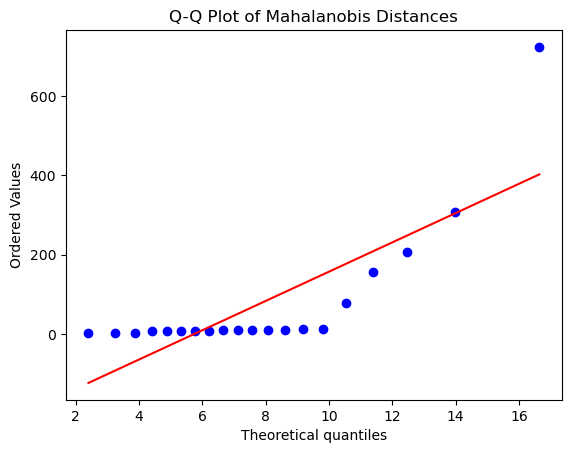

Henze-Zirkler Test:
 HZResults(hz=1.0795278119755913, pval=1.5825002782747915e-06, normal=False)


In [ ]:
# Select only the dependent variables (DVs)
X = scores_df[dv_columns].dropna()

# Compute robust Mahalanobis distances
robust_cov = MinCovDet().fit(X)
mahalanobis_distances = robust_cov.mahalanobis(X)

# Chi-squared Q-Q plot
probplot(mahalanobis_distances, dist="chi2", sparams=(len(dv_columns),), plot=plt)
plt.title("Q-Q Plot of Mahalanobis Distances")
plt.show()

# Formal multivariate normality test (Henze-Zirkler's)
normality_test = pg.multivariate_normality(scores_df[dv_columns], alpha=0.05)
print("Henze-Zirkler Test:\n", normality_test)


In [5]:
# Calculate the threshold for outliers
threshold = chi2.ppf(0.99, df=len(dv_columns))
outliers = mahalanobis_distances > threshold
# Print the number of outliers
print(f"Outlier count: {np.sum(outliers)}")
# identifying the outliers
outlier_indices = np.where(outliers)[0]
outlier_rows = scores_df.iloc[outlier_indices]
print("Outlier rows:")
print(outlier_rows)


Outlier count: 5
Outlier rows:
    chunk_size  max_tokens    rouge1    rouge2    rougeL  rougeLsum  \
0          128         128  0.240665  0.171811  0.209919   0.229688   
3          128        1024  0.351167  0.231052  0.284325   0.332217   
4          128        2048  0.347461  0.221321  0.275704   0.326842   
15        1024         128  0.031999  0.021180  0.028436   0.031318   
17        1024         512  0.081810  0.059997  0.070784   0.080223   

    bert_score_P  bert_score_R  bert_score_F1  sts_score substring_date  
0       0.714532      0.440610       0.539756   0.559266  LMForge_RUN02  
3       0.691136      0.520246       0.585593   0.609433  LMForge_RUN02  
4       0.679636      0.520178       0.581982   0.618118  LMForge_RUN02  
15      0.593533      0.313629       0.406797   0.360901  LMForge_RUN02  
17      0.637666      0.376273       0.467231   0.447940  LMForge_RUN02  


In [6]:
## homogeneity of covariance matrices 
# Box's M test
scores_df["group"] = scores_df["chunk_size"].astype(str)

# Then re-clean and re-test
df_clean = scores_df.dropna(subset=dv_columns + ["group"])
box_m = pg.box_m(data=df_clean, dvs=dv_columns, group='group')
print("Box’s M Test:\n", box_m)

Box’s M Test:
      Chi2     df  pval  equal_cov
box   inf  108.0   0.0      False


/opt/anaconda3/lib/python3.12/site-packages/pingouin/multivariate.py:386: RuntimeWarning: divide by zero encountered in log
  u = -2 * (1 - c) * np.log(M)


In [7]:
threshold = chi2.ppf(0.999, df=X.shape[1])  # 99.9% cutoff
outlier_flags = mahalanobis_distances > threshold
num_outliers = np.sum(outlier_flags)

# summary of outlier results
outlier_summary = pd.DataFrame([{
    "Total Observations": len(mahalanobis_distances),
    "Outliers Detected (p < 0.001)": num_outliers,
    "Percentage Outliers": 100 * num_outliers / len(mahalanobis_distances)
}])
print(outlier_summary)

   Total Observations  Outliers Detected (p < 0.001)  Percentage Outliers
0                  20                              5                 25.0


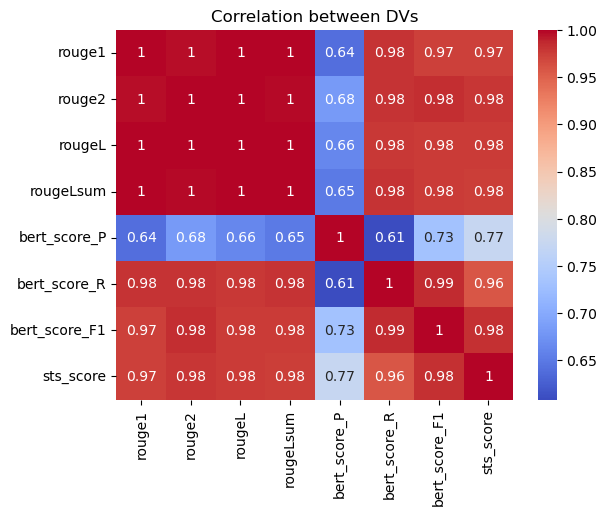

In [ ]:
# Check correlation between DVs
sns.heatmap(scores_df[dv_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between DVs")
plt.show()


In [ ]:
# Check for multicollinearity

# Add a constant to the model
X_with_const = add_constant(X)
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print(vif_data)

         feature           VIF
0          const   8996.863254
1         rouge1  88353.609271
2         rouge2   4995.350022
3         rougeL  12965.565541
4      rougeLsum  62530.524231
5   bert_score_P    193.709623
6   bert_score_R   4317.033541
7  bert_score_F1   4684.069453
8      sts_score    193.722995


In [ ]:
# Define DVs
dv_columns = [
    "rouge1", "rouge2", "rougeL", "rougeLsum",
    "bert_score_P", "bert_score_R", "bert_score_F1", "sts_score"
]

# Create group variable
scores_df["group"] = scores_df["chunk_size"].astype(str)

# Drop missing
df_simple = scores_df.dropna(subset=dv_columns + ["group"])

# Create MANOVA formula
formula_simple = " + ".join(dv_columns) + " ~ group"

# Fit MANOVA
maov_simple = MANOVA.from_formula(formula_simple, data=df_simple)
print(maov_simple.mv_test())


                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept          Value   Num DF Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda    0.0002 8.0000 9.0000 5157.1422 0.0000
         Pillai's trace    0.9998 8.0000 9.0000 5157.1422 0.0000
 Hotelling-Lawley trace 4584.1264 8.0000 9.0000 5157.1422 0.0000
    Roy's greatest root 4584.1264 8.0000 9.0000 5157.1422 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
         group           Value    Num DF  Den DF F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda   0.0000 24.0000 26.7040  44.8593 0.0000
         Pillai's trace   2.6072 24.0000 33.0

In [ ]:
# Type III ANOVA

# Fit the model using OLS
def type_3(formula, data):
    """
    Perform Type III ANOVA using the given formula and data.
    """
    model = ols(formula, data=data).fit()
    anova_results = anova_lm(model, typ=3)
    return anova_results

# Perform Type III ANOVA for each dependent variable
results = []
for column in dv_columns:
    formula = f"{column} ~ group"
    anova_results = type_3(formula, df_clean)
    print(f"ANOVA results for {column}:\n", anova_results)
    results.append((column, anova_results))

# results
anova_results_dict = {column: result for column, result in results}



ANOVA results for rouge1:
              sum_sq    df          F    PR(>F)
Intercept  0.029093   1.0  13.816819  0.001873
group      0.178835   3.0  28.310453  0.000001
Residual   0.033690  16.0        NaN       NaN
ANOVA results for rouge2:
              sum_sq    df          F    PR(>F)
Intercept  0.016336   1.0  16.238389  0.000970
group      0.072025   3.0  23.865055  0.000004
Residual   0.016096  16.0        NaN       NaN
ANOVA results for rougeL:
              sum_sq    df          F        PR(>F)
Intercept  0.022291   1.0  17.462634  7.092123e-04
group      0.113757   3.0  29.704922  8.945681e-07
Residual   0.020424  16.0        NaN           NaN
ANOVA results for rougeLsum:
              sum_sq    df          F    PR(>F)
Intercept  0.028120   1.0  14.524290  0.001536
group      0.156535   3.0  26.950182  0.000002
Residual   0.030978  16.0        NaN       NaN
ANOVA results for bert_score_P:
              sum_sq    df            F        PR(>F)
Intercept  2.036713   1.0  6344.848

In [ ]:
scores_df["group"] = scores_df["chunk_size"].astype(str)
df_simple = scores_df.dropna(subset=dv_columns + ["group"])

# Create distance matrix and group labels reference: https://scikit.bio/docs/dev/generated/skbio.stats.distance.html
X = df_simple[dv_columns].values
group_labels = df_simple["group"].values
distance_matrix = DistanceMatrix(squareform(pdist(X, metric='euclidean')))

# Run PERMANOVA
results = permanova(distance_matrix, grouping=group_labels, permutations=999)
print("PERMANOVA results for chunk_size groups:")
print(results)



scores_df["group2"] = scores_df[["max_tokens"]].astype(str)
# Create distance matrix and group labels
X2 = scores_df[dv_columns].values
distance_matrix2 = DistanceMatrix(squareform(pdist(X2, metric='euclidean')))
# Run PERMANOVA for the second group
results2 = permanova(distance_matrix2, grouping=scores_df["group2"].values, permutations=999)
print("PERMANOVA results for max_tokens groups:")
print(results2)



PERMANOVA results for chunk_size groups:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      20
number of groups                  4
test statistic            23.744764
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object
PERMANOVA results for max_tokens groups:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      20
number of groups                  5
test statistic             0.736644
p-value                       0.565
number of permutations          999
Name: PERMANOVA results, dtype: object


MANOVA results on PCA components:
                  Multivariate linear model
                                                            
------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.2891 2.0000 15.0000 18.4387 0.0001
         Pillai's trace 0.7109 2.0000 15.0000 18.4387 0.0001
 Hotelling-Lawley trace 2.4585 2.0000 15.0000 18.4387 0.0001
    Roy's greatest root 2.4585 2.0000 15.0000 18.4387 0.0001
------------------------------------------------------------
                                                            
------------------------------------------------------------
         group          Value  Num DF  Den DF F Value Pr > F
------------------------------------------------------------
          Wilks' lambda 0.0639 6.0000 30.0000 14.7822 0.0000
         Pillai's trace 1.4756 6.0000 32.0000 15.0083 0.0000
 Hotell

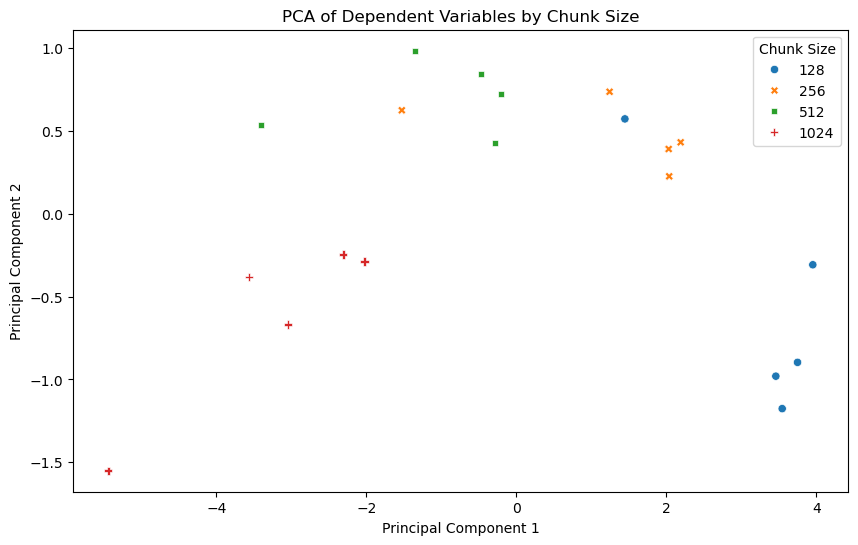

In [27]:
# PCA + MANOVA 
scores_df["group"] = scores_df["chunk_size"].astype(str)
df_clean = scores_df.dropna(subset=dv_columns + ["group"])

# Standardize the dependent variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[dv_columns])

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add principal components to the dataframe
df_clean["PC1"] = X_pca[:, 0]
df_clean["PC2"] = X_pca[:, 1]

# Run MANOVA on the first two principal components
from statsmodels.multivariate.manova import MANOVA
maov_pca = MANOVA.from_formula("PC1 + PC2 ~ group", data=df_clean)
manova_pca_results = maov_pca.mv_test()
print("MANOVA results on PCA components:\n", manova_pca_results)
# Plot PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="PC1", y="PC2", hue="group", style="group")
plt.title("PCA of Dependent Variables by Chunk Size")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Chunk Size")
plt.show()

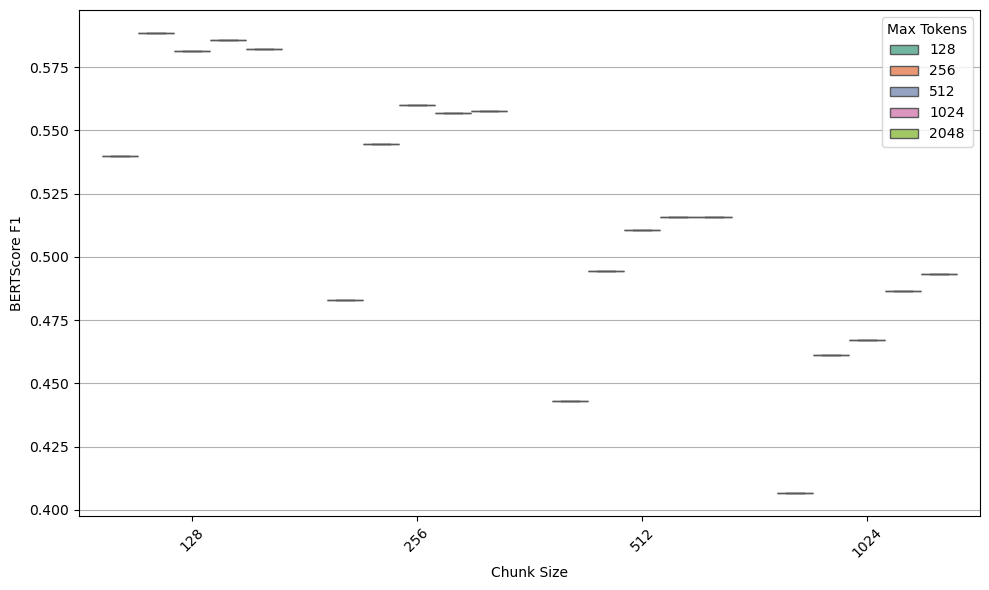

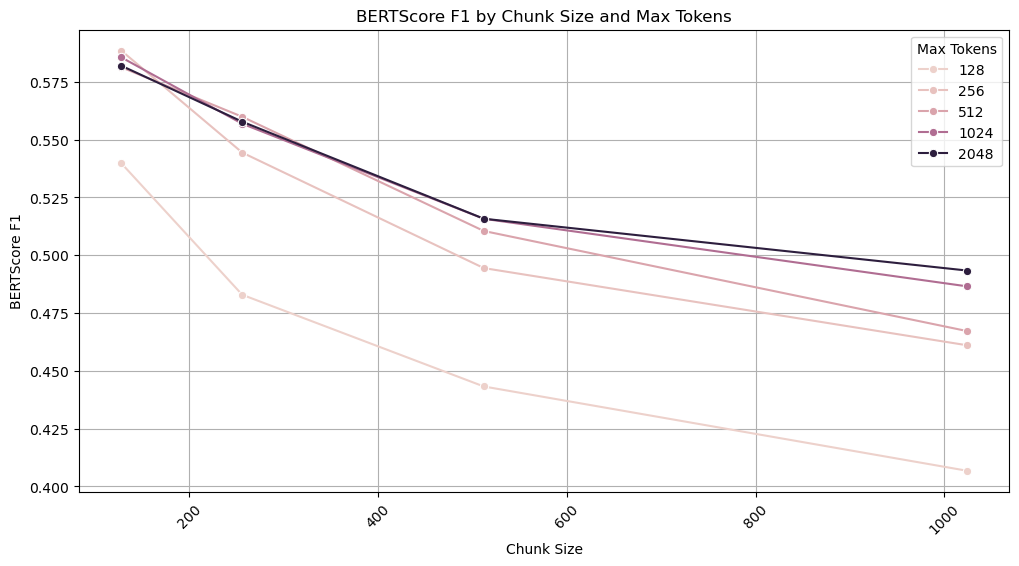

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='chunk_size', y='bert_score_F1', hue='max_tokens', data=scores_df, palette="Set2")
plt.xlabel("Chunk Size")
plt.ylabel("BERTScore F1")
plt.xticks(rotation=45)
plt.legend(title="Max Tokens")
plt.grid(axis='y')
plt.tight_layout()
plt.figure(figsize=(12, 6))
sns.lineplot(data=scores_df, x='chunk_size', y='bert_score_F1', hue='max_tokens', marker='o')
plt.xlabel("Chunk Size")
plt.ylabel("BERTScore F1")
plt.title("BERTScore F1 by Chunk Size and Max Tokens")
plt.xticks(rotation=45)
plt.legend(title="Max Tokens")
plt.grid()

In [6]:
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

pairwise_results = []
scores_df["group"] = scores_df["chunk_size"].astype(str)

# Looping through the combinations of groups
for grp1, grp2 in combinations(scores_df["group"].unique(), 2):
    subset = scores_df[scores_df["group"].isin([grp1, grp2])].copy()
    subset = subset.reset_index(drop=True)
    
    # Distance matrix
    X_pair = subset[dv_columns].values
    distance_array = squareform(pdist(X_pair, metric='euclidean'))
    ids = [str(i) for i in subset.index]
    distance_matrix = DistanceMatrix(distance_array, ids=ids)
    
    # DataFrame with group labels
    grouping_df = pd.DataFrame({'group': subset["group"].values}, index=ids)
    
    # PERMANOVA 
    result = permanova(distance_matrix, grouping=grouping_df, column='group', permutations=999)
    
    pairwise_results.append({
        "Group 1": grp1,
        "Group 2": grp2,
        "Pseudo-F": result["test statistic"],
        "p-value": result["p-value"]
    })

pairwise_df = pd.DataFrame(pairwise_results)
print(pairwise_df)


  Group 1 Group 2   Pseudo-F  p-value
0     128     256   7.242994    0.029
1     128     512  36.159047    0.007
2     128    1024  75.109721    0.009
3     256     512   7.081500    0.030
4     256    1024  23.854621    0.010
5     512    1024   6.190598    0.035


In [12]:
# Compute group means
group_means = scores_df.groupby('chunk_size')[dv_columns].mean().mean(axis=1).sort_index()
print("Group Means:")
print(group_means)

differences = []
# Calculate differences between each pair of groups
for (grp1, grp2) in combinations(group_means.index, 2):
    diff = group_means[grp2] - group_means[grp1]
    differences.append({
        "Group 1": grp1,
        "Group 2": grp2,
        "Mean Difference": diff
    })

differences_df = pd.DataFrame(differences)
print("Mean Differences between Groups:")
print(differences_df)


Group Means:
chunk_size
128     0.436578
256     0.381648
512     0.321881
1024    0.271981
dtype: float64
Mean Differences between Groups:
   Group 1  Group 2  Mean Difference
0      128      256        -0.054930
1      128      512        -0.114697
2      128     1024        -0.164598
3      256      512        -0.059767
4      256     1024        -0.109668
5      512     1024        -0.049901


In [8]:
# Step 1: Compute group means per DV
group_means = scores_df.groupby('chunk_size')[dv_columns].mean().sort_index()
print("Group Means:")
print(group_means)

# Step 2: Compute pairwise mean differences for each DV
differences = []
chunk_sizes = group_means.index.tolist()

for dv in dv_columns:
    for grp1, grp2 in combinations(chunk_sizes, 2):
        diff = group_means.loc[grp2, dv] - group_means.loc[grp1, dv]
        differences.append({
            "Dependent Variable": dv,
            "Group 1": grp1,
            "Group 2": grp2,
            "Mean Difference": diff
        })

# Step 3: Convert to DataFrame
differences_df = pd.DataFrame(differences)
print("Mean Differences between Groups for Each DV:")
print(differences_df)

Group Means:
              rouge1    rouge2    rougeL  rougeLsum  bert_score_P  \
chunk_size                                                          
128         0.325832  0.216365  0.266557   0.308374      0.696190   
256         0.231468  0.158992  0.191592   0.223323      0.709704   
512         0.138051  0.100932  0.118642   0.134836      0.695675   
1024        0.076280  0.057159  0.066770   0.074994      0.638234   

            bert_score_R  bert_score_F1  sts_score  
chunk_size                                          
128             0.501457       0.575429   0.602425  
256             0.445231       0.540396   0.552478  
512             0.392216       0.495966   0.498733  
1024            0.370272       0.463017   0.429117  
Mean Differences between Groups for Each DV:
   Dependent Variable  Group 1  Group 2  Mean Difference
0              rouge1      128      256        -0.094364
1              rouge1      128      512        -0.187781
2              rouge1      128     102

In [ ]:
from scipy.stats import ttest_ind
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Pairwise t-tests for each dependent variable
results = []
for dv in dv_columns:
    for grp1, grp2 in combinations(scores_df["chunk_size"].unique(), 2):
        vals1 = scores_df[scores_df["chunk_size"] == grp1][dv]
        vals2 = scores_df[scores_df["chunk_size"] == grp2][dv]
        t_stat, p_val = ttest_ind(vals1, vals2, equal_var=False)
        results.append({
            "Outcome": dv,
            "Group 1": grp1,
            "Group 2": grp2,
            "t-statistic": t_stat,
            "raw p-value": p_val
        })

ttest_df = pd.DataFrame(results)

# Applying the FDR (Benjamini-Hochberg) correction
reject, fdr_pvals, sidak_thresh, bonf_thresh = multipletests(ttest_df["raw p-value"], method='fdr_bh')
ttest_df["FDR (BH) p-value"] = fdr_pvals
ttest_df["Significant (FDR < 0.05)"] = reject

# results
print(ttest_df.head())
ttest_df.to_csv("pairwise_ttests_fdr.csv", index=False)


  Outcome  Group 1  Group 2  t-statistic  raw p-value  FDR (BH) p-value  \
0  rouge1      128      256     2.851769     0.022036          0.037495   
1  rouge1      128      512     6.401473     0.000212          0.001272   
2  rouge1      128     1024     9.856474     0.000029          0.000346   
3  rouge1      256      512     2.891892     0.021223          0.037495   
4  rouge1      256     1024     5.406126     0.001538          0.004407   

   Significant (FDR < 0.05)  
0                      True  
1                      True  
2                      True  
3                      True  
4                      True  
